## Individuell inlämningsuppgift – Deep Learning

# Marcus Bäckström


In [ ]:
# Grundläggande bibliotek
import time

import os
from PIL import Image

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)
train_dir = "Data/train"
test_dir = "Data/test"

# Funktions

In [ ]:
# Load images from folder and give it a class and put it in y based on folder title.

def load_images_from_folder(dir, image_size=(48, 48), max_per_class = None ):

    X = []
    y = []
    class_names = sorted(os.listdir(dir))

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path)

        if  max_per_class is not None:
            images = images[:max_per_class]

        for img_file in images:
            img_path = os.path.join(class_path, img_file)

            try:
                img = Image.open(img_path).convert("L") # Convert to grayscale in case they are not grayscale.
                img = img.resize(image_size)
                X.append(np.array(img))
                y.append(label)
            except:
                pass    
    


    return  np.array(X), np.array(y), class_names

In [ ]:
# Plot images taken randomly with n_images with how many.

def plot_image_grid(X,y, class_names, n_images=25, random_state=42, afigsize=(12, 12) ):

    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images) ) )

    plt.figure(figsize=afigsize)

    for plot_index, image_index in enumerate(indices):
        
        plt.subplot(grid_size, grid_size, plot_index + 1)

        plt.imshow(X[image_index], cmap="gray")

        plt.title(class_names[y[image_index] ], fontsize=9 )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [28]:
# Plot Loss and Accuracy by epoch´s

def plot_history(history, title="", afigsize=(12, 4) ):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=afigsize)

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training Loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation Loss")

    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")

    plt.ylim(0,2.5)
    plt.xlim(1, len(history_df) )

    plt.legend()

    plt.suptitle(title)
    
    plt.figure(figsize=afigsize )

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["accuracy"], label="Training Accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation Accuracy")

    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")

    plt.ylim(0,1)
    plt.xlim(1, len(history_df) )

    plt.legend()

    plt.suptitle(title)

    plt.tight_layout()
    plt.show()

In [ ]:
# Build model´s with adjustable params

def build_custom_models(
        input_shape = (48, 48, 1), 
        l2_unit = 0.0, blocks = 1,
        convs_per_block = 1, 
        filters =[32, 64, 128], 
        kernel_size = (3,3), 
        conv_dropout = 0,
        dense_dropout = 0,
        dense_units = 128,
        learning_rate = 0.001 ):

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_shape) ) )

    # L2 regulaisering.
    kernel_regularizer = (keras.regularizers.l2(l2_unit) if l2_unit > 0 else None)

    for b in range(blocks):

        for c in range(convs_per_block):

            model.add(
                layers.Conv2D(
                    filters=filters[b],
                    kernel_size=kernel_size,
                    activation="relu",
                    padding="same",
                    kernel_regularizer=kernel_regularizer
                )
            )
        model.add(layers.MaxPooling2D(pool_size=(2 , 2)))

        if conv_dropout > 0 :
            model.add(layers.Dropout(conv_dropout))

    model.add(layers.Flatten())

    model.add(
        layers.Dense(
            dense_units,
            activation="relu",
            kernel_regularizer=kernel_regularizer
        )
    )

    if dense_dropout > 0:
        model.add(layers.Dropout(dense_dropout))

    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
        loss = keras.losses.SparseCategoricalCrossentropy(),
        metrics = ["accuracy"]
    )


    return model



In [ ]:
# Make Early Stopping Callback

def build_early_stopping_callback(early_patience=3, early_monitor="val_loss"):
   
    callbacks = []
    callbacks.append(
        keras.callbacks.EarlyStopping(
            monitor=early_monitor,
            patience=early_patience,
            restore_best_weights=True
        )

    )

    return callbacks

# Early peek at the Data

In [ ]:
class_names_train = sorted(os.listdir(train_dir))
print(f"Train Klasser : {class_names_train}")
class_names_test = sorted(os.listdir(test_dir))
print(f"Test Klasser : {class_names_test}")

In [ ]:
class_distribution_train = pd.DataFrame({
    "train_class_name": class_names_train,
    "count": [len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names_train]
})

class_distribution_test = pd.DataFrame({
    "test_class_name": class_names_test,
    "count": [len(os.listdir(os.path.join(test_dir, cls))) for cls in class_names_test]
})

display(class_distribution_train)
display(class_distribution_test)

In [ ]:
print("Totalt antal träningsbilder:", class_distribution_train["count"].sum())
print("Totalt antal testbilder:", class_distribution_test["count"].sum())


# Load image: 

## Small batch

In [ ]:

X_train_full, y_train_full, class_names = load_images_from_folder(
    train_dir, 
    max_per_class=300
)

print(f"X_train_full Shape : {X_train_full.shape}")
print(f"y_train_full Shape : {y_train_full.shape}")
print(f"Class Names : {class_names}")

# Check Loaded Images

In [ ]:
class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

In [ ]:
plot_image_grid(
    X=X_train_full,
    y=y_train_full,
    class_names=class_names,
    n_images=25
)

In [ ]:
print("Minsta pixel värde : ", X_train_full.min())
print("Största pixel värde : ", X_train_full.max())

# Train Val 

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    random_state=42,
    test_size=0.10,
    stratify=y_train_full
)

print(f"X_train Shape :  {X_train.shape}")
print(f"y_train Shape :  {y_train.shape}")
print(f"X_val Shape :  {X_val.shape}")
print(f"y_val Shape :  {y_val.shape}")


# Format/Scale data

In [ ]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

In [ ]:
# add channel as cnn model need 3 vector, X, Y, Z.
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]

print("X_train Shape efter kanal-dimension", X_train.shape)
print("X_val Shape efter kanal-dimension", X_val.shape)


# Begin Models

### Baseline Model

In [ ]:
# without using funktion.

# baseline_model = keras.Sequential([

#     layers.Input(shape=(48, 48, 1)),

#     layers.Conv2D(
#         filters=32,
#         kernel_size=(3, 3),
#         activation="relu",
#         padding="same"
#     ),

#     layers.MaxPooling2D(2, 2),

    
#     layers.Conv2D(
#         filters=64,
#         kernel_size=(3, 3),
#         activation="relu",
#         padding="same"
#     ),

#     layers.MaxPooling2D(2, 2),

#     layers.Flatten(),

#     layers.Dense(64, activation="relu"),


#     layers.Dense(10, activation="softmax")

# ])

# baseline_model.summary()

In [ ]:
# baseline_model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss=keras.losses.SparseCategoricalCrossentropy(),
#     metrics=["accuracy"]
# )

In [ ]:
# baseline_history = baseline_model.fit(
#     X_train,
#     y_train,
#     validation_data=(X_val, y_val),
#     epochs=5,
#     batch_size=32
# )

In [ ]:
baseline_model_funktion = build_custom_models(blocks=2, dense_units=64)
baseline_model_funktion.summary()

In [26]:
baseline_history_funktion = baseline_model_funktion.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs = 10,
    batch_size=32
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.1503 - loss: 1.9934 - val_accuracy: 0.1905 - val_loss: 1.9203
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2138 - loss: 1.9045 - val_accuracy: 0.2524 - val_loss: 1.8797
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.2661 - loss: 1.8140 - val_accuracy: 0.2857 - val_loss: 1.8361
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.3190 - loss: 1.7226 - val_accuracy: 0.3190 - val_loss: 1.8054
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3661 - loss: 1.6258 - val_accuracy: 0.3238 - val_loss: 1.8077
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4339 - loss: 1.5195 - val_accuracy: 0.3429 - val_loss: 1.8146
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4968 - loss: 1.4012 - val_accuracy: 0.3238 - val_loss: 1.8611
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5513 - loss: 1.2720 - val_accuracy: 0.3143 - v

# Plot baseline

In [ ]:
# plot_history(baseline_history)

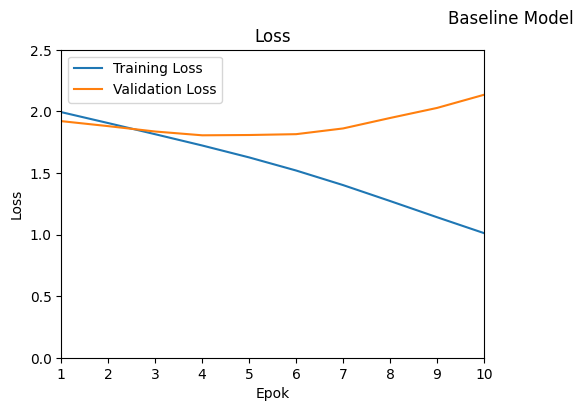

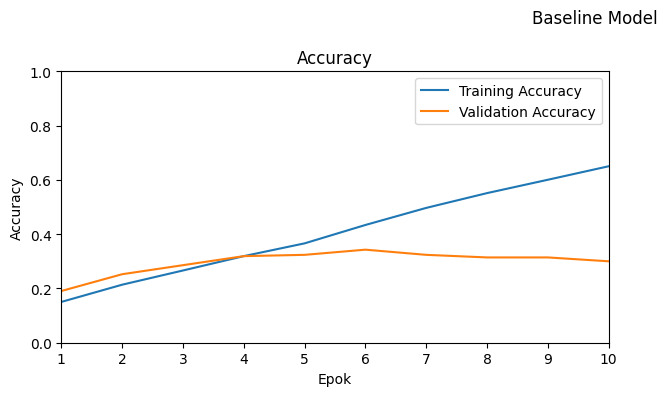

In [30]:
plot_history(baseline_history_funktion,title="Baseline Model")

# Save Model & History

In [ ]:
# baseline_model.save("Models/baseline_model.keras")

In [ ]:
loaded_baseline_model = keras.models.load_model("Models/baseline_model.keras")

# Made with help from AI as i asked how to save and load history i dont need to do fit every time

In [ ]:
with open("Histories/baseline_history.json", "w") as f:
    json.dump(baseline_history.history, f)

In [ ]:
with open("Histories/baseline_history.json", "r") as f:
    baseline_history_data = json.load(f)

In [ ]:
class FakeHistory:
    def __init__(self, history_dict):
        self.history = history_dict

loaded_baseline_history = FakeHistory(baseline_history_data)

# #

In [ ]:
plot_history(loaded_baseline_history)